In [ ]:
!pip install xgboost shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('cleaned_data.csv')
print("Shape:", df.shape)
print("Loaded successfully!")

Shape: (2236, 33)
Loaded successfully!


In [ ]:
# Recency — how many days since they joined
import datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
reference_date = df['Dt_Customer'].max()
df['Recency'] = (reference_date - df['Dt_Customer']).dt.days

# Frequency — total number of purchases
df['Frequency'] = (df['NumWebPurchases'] +
                   df['NumStorePurchases'] +
                   df['NumCatalogPurchases'])

# Monetary — already created in Phase 3
# Total_Spend column exists already

# Show RFM summary
print("=== RFM Feature Summary ===")
print(df[['Recency', 'Frequency', 'Total_Spend']].describe())

=== RFM Feature Summary ===
           Recency    Frequency  Total_Spend
count  2236.000000  2236.000000  2236.000000
mean    353.773256    12.546512   605.986583
std     202.181561     7.206577   601.865156
min       0.000000     0.000000     5.000000
25%     180.750000     6.000000    69.000000
50%     356.000000    12.000000   396.500000
75%     529.000000    18.000000  1045.500000
max     699.000000    32.000000  2525.000000


In [ ]:
# K-Means is sensitive to scale
# Income (50,000) vs Frequency (15) are very different scales
# Scaling brings everything to the same range

scaler = StandardScaler()
rfm_features = df[['Recency', 'Frequency', 'Total_Spend']]
rfm_scaled = scaler.fit_transform(rfm_features)

print("Scaling complete!")
print(f"Original Recency range: {df['Recency'].min()} to {df['Recency'].max()}")
print(f"Original Frequency range: {df['Frequency'].min()} to {df['Frequency'].max()}")
print(f"Original Spend range: {df['Total_Spend'].min()} to {df['Total_Spend'].max()}")

Scaling complete!
Original Recency range: 0 to 699
Original Frequency range: 0 to 32
Original Spend range: 5 to 2525


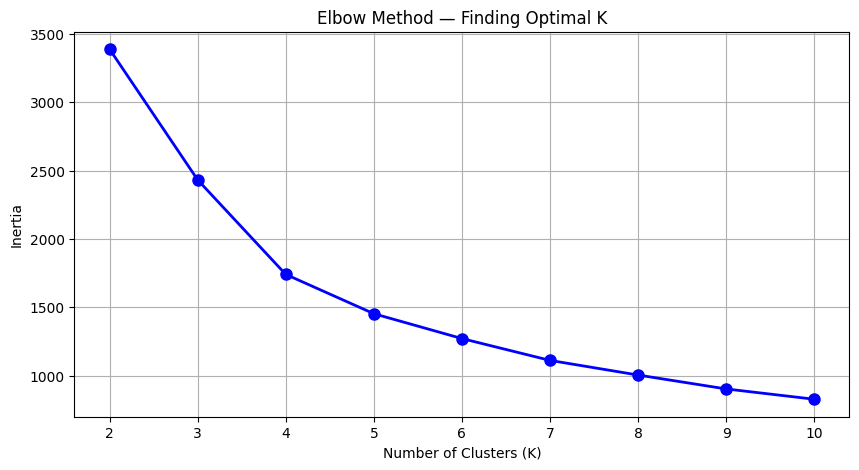

Look at the chart — find where the curve bends like an elbow
That K value is your optimal number of clusters


In [ ]:
# We need to find the best number of clusters
# Elbow method runs K-Means for different K values
# and finds where adding more clusters stops helping

inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Optimal K')
plt.xticks(k_range)
plt.grid(True)
plt.show()

print("Look at the chart — find where the curve bends like an elbow")
print("That K value is your optimal number of clusters")

In [ ]:
# Apply K-Means with optimal K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(rfm_scaled)

# See how many customers in each cluster
print("=== Customers per Cluster ===")
print(df['Cluster'].value_counts().sort_index())

=== Customers per Cluster ===
Cluster
0    646
1    520
2    597
3    473
Name: count, dtype: int64


In [ ]:
# Calculate average RFM per cluster to understand each group
cluster_summary = df.groupby('Cluster')[['Recency',
                                          'Frequency',
                                          'Total_Spend']].mean().round(2)
print("=== Cluster Profiles ===")
print(cluster_summary)

=== Cluster Profiles ===
         Recency  Frequency  Total_Spend
Cluster                                 
0         171.54       6.42       116.60
1         540.84      20.01      1268.65
2         516.57       7.67       184.73
3         191.52      18.87      1077.54


In [ ]:
# After seeing cluster_summary, assign meaningful names
# The labels below may need adjusting based on your results

cluster_labels = {
    0: 'At-Risk',
    1: 'Champions',
    2: 'Loyal',
    3: 'Lost'
}

df['Customer_Segment'] = df['Cluster'].map(cluster_labels)
print(df['Customer_Segment'].value_counts())

Customer_Segment
At-Risk      646
Loyal        597
Champions    520
Lost         473
Name: count, dtype: int64


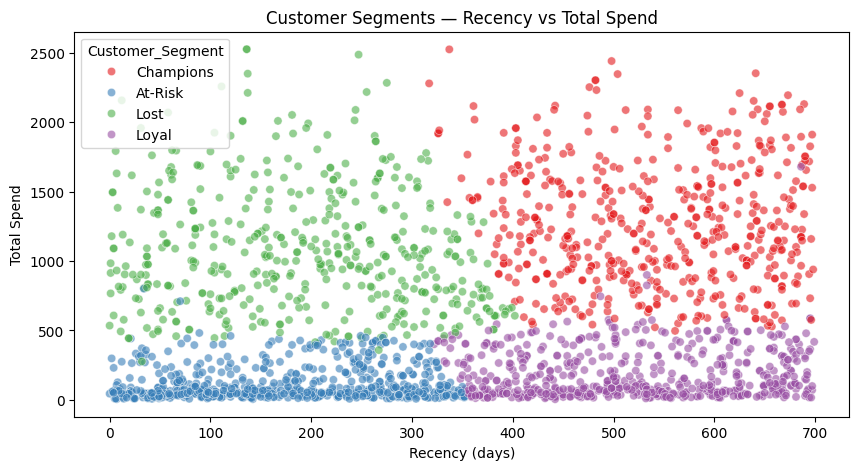

In [ ]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df,
                x='Recency',
                y='Total_Spend',
                hue='Customer_Segment',
                palette='Set1',
                alpha=0.6)
plt.title('Customer Segments — Recency vs Total Spend')
plt.xlabel('Recency (days)')
plt.ylabel('Total Spend')
plt.show()

In [ ]:
# Select features that help predict Total_Spend
features = ['Age', 'Income', 'Customer_Tenure', 'Recency',
            'Frequency', 'AcceptedCmp1', 'AcceptedCmp2',
            'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
            'NumWebPurchases', 'NumStorePurchases',
            'NumCatalogPurchases', 'Total_Campaigns_Accepted']

target = 'Total_Spend'

X = df[features]
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print(f"\nAverage Total Spend: £{y.mean():.2f}")
print(f"Min Spend: £{y.min():.2f}")
print(f"Max Spend: £{y.max():.2f}")

Features shape: (2236, 14)
Target shape: (2236,)

Average Total Spend: £605.99
Min Spend: £5.00
Max Spend: £2525.00


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("=== Data Split ===")
print(f"Training set: {X_train.shape[0]} customers (80%)")
print(f"Testing set:  {X_test.shape[0]} customers (20%)")

=== Data Split ===
Training set: 1788 customers (80%)
Testing set:  448 customers (20%)


In [ ]:
# Create and train the model
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)
print("✅ Model trained successfully!")

✅ Model trained successfully!


In [ ]:
# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate performance metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Model Performance ===")
print(f"RMSE: £{rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"\nInterpretation:")
print(f"Model predictions are off by £{rmse:.2f} on average")
print(f"Model explains {r2*100:.1f}% of variance in customer spend")

=== Model Performance ===
RMSE: £202.76
R² Score: 0.8909

Interpretation:
Model predictions are off by £202.76 on average
Model explains 89.1% of variance in customer spend


In [ ]:
# Predict CLV for ALL customers
df['Predicted_CLV'] = model.predict(X)

# Classify into tiers based on predicted value
df['CLV_Tier'] = pd.cut(df['Predicted_CLV'],
                         bins=3,
                         labels=['Low CLV', 'Mid CLV', 'High CLV'])

print("=== CLV Tier Distribution ===")
print(df['CLV_Tier'].value_counts())
print(f"\nAverage predicted CLV by tier:")
print(df.groupby('CLV_Tier')['Predicted_CLV'].mean().round(2))

=== CLV Tier Distribution ===
CLV_Tier
Low CLV     1427
Mid CLV      638
High CLV     171
Name: count, dtype: int64

Average predicted CLV by tier:
CLV_Tier
Low CLV      217.550003
Mid CLV     1158.260010
High CLV    1760.819946
Name: Predicted_CLV, dtype: float32


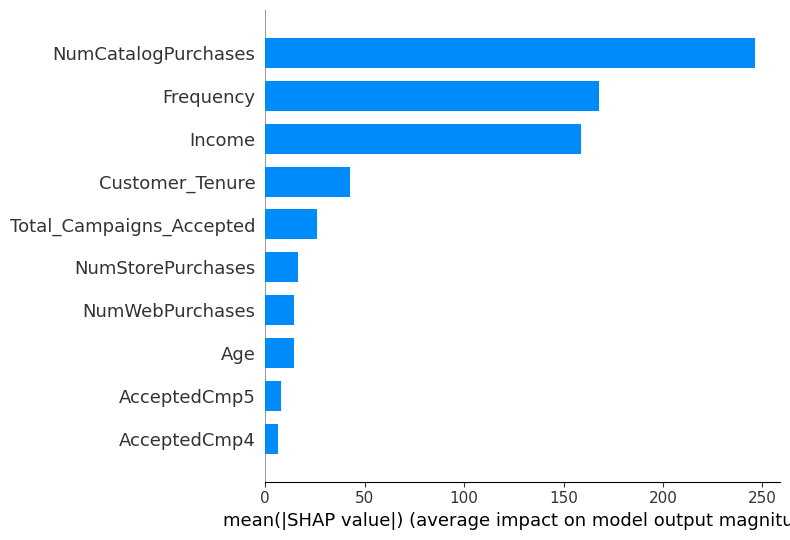

In [ ]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Summary plot — most important features
shap.summary_plot(shap_values, X_test,
                  plot_type="bar",
                  max_display=10)

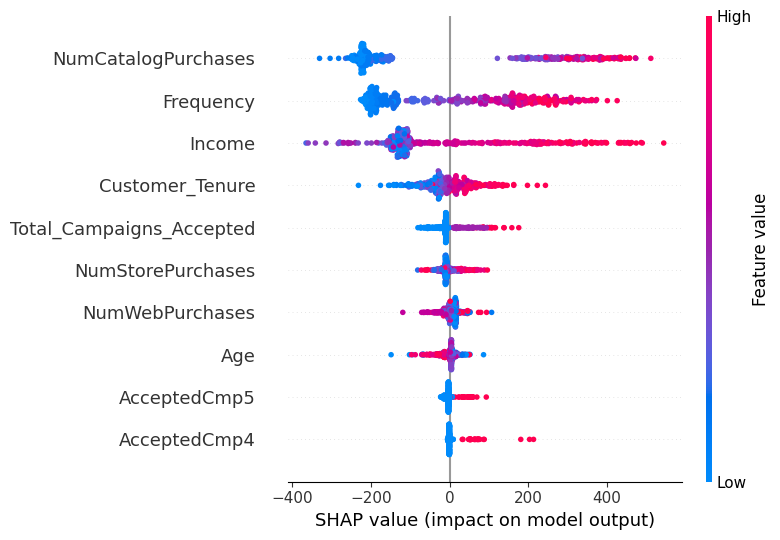

In [ ]:
shap.summary_plot(shap_values, X_test, max_display=10)

In [ ]:
# Save each customer with their segment and CLV tier
output = df[['Income', 'Age', 'Total_Spend',
             'Recency', 'Frequency',
             'Customer_Segment', 'CLV_Tier',
             'Predicted_CLV']].copy()

output.to_csv('customer_segments.csv', index=False)

from google.colab import files
files.download('customer_segments.csv')
print("✅ Saved successfully!")
print(f"Shape: {output.shape}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Saved successfully!
Shape: (2236, 8)
